
# Try to optimized $\beta$ and $\theta$ of th Rio 2014 stationnary model

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250m, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import put_fig_letter, update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

# Data

In [2]:
DT = 3
distance_to_coast_max = 20e3

In [5]:
band = ['', 'LF', 'inertial', 'diurnal', 'semidiurnal', 'HF']

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = 'spectral_decomp',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list =[base_dic]


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0 = ds0.where(ds0.depth==0, drop=True)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

# Correct mean geostrophic
#ds0 = extract_mean_geo(ds0)
df0 = ds0.to_dataframe().reset_index().set_index('row_number')

#DEPTH 15M
base_dic = update_dict(base_dic, {'wd_depth':'15'})

comb_list = [base_dic]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15 =ds15.where(ds15.depth==15, drop=True)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

# Correct mean geostrophic
#ds15 = extract_mean_geo(ds15)
df15 = ds15.to_dataframe().reset_index().set_index('row_number')

321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
Identified SWOT and drifter outliers have been removed


In [6]:
df0['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df0.latitude * np.pi / 180)
df15['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(df15.latitude * np.pi / 180)


In [7]:
# Wind data
dfw = pd.read_parquet(os.path.join(zarr_dir,'coloc_files','wind','era5_rioagesc_12h_spectral_decomp_all_med_variational_10min_v1.parquet'))#.set_index('row_number')

# all in one 
DSl=[pd.concat([df0, dfw[['iews', 'inss']]], axis=1).dropna().to_xarray(), 
     pd.concat([df15, dfw[['iews', 'inss']]], axis=1).dropna().to_xarray()
    ]

In [8]:
def update_wdterm(beta0, theta0, dsi):
    ds = dsi.copy()
    theta0 = - theta0 * np.pi / 180 * np.sign(ds.f)
    uek_e = beta0 * (np.cos(theta0) * ds.iews - np.sin(theta0) * ds.inss)
    uek_n = beta0 * (np.sin(theta0) * ds.iews + np.cos(theta0) * ds.inss)
    ds['wde'] = ds.f * uek_n
    ds['wdn'] = -ds.f * uek_e

    for direction in ['e', 'n'] : 
        if direction == 'e' : l = {'acc':'acce', 'cor':'core', 'ggd':'ggde', 'wd':'wde'}
        if direction == 'n' : l = {'acc':'accn', 'cor':'corn', 'ggd':'ggdn', 'wd':'wdn'}
            
        # sum 
        ds['sum'+direction] = sum([ds[l[v]] for v in l])
    
        # simple var + sum- one term
        for v in l :
            ds[l[v]] = ds[l[v]]
            ds['exc'+direction+'_'+v] = ds['sum'+direction]-ds[l[v]]
            
        #2 by 2 product    
        import itertools  
        couple = list(itertools.combinations(list(l.keys()),2))
        for c in couple : 
            ds['prod'+direction+'_'+'_'.join(c)] = ds[c[0]+direction] * ds[c[1]+direction]
            
    return ds

In [27]:
# Surface optimisation

db = 1
dt = 30
DSB =[]
#list_beta0 = np.linspace(0, 1.5, 25)
list_theta0 = np.arange(20, 40, 1)
list_beta0 = np.arange(0.8, 1.3, 0.025)
#list_theta0 = np.linspace(32, 35, 25)
DSM = []
ds = DSl[0]
for theta0 in list_theta0 : 
    D=[]
    for beta0 in list_beta0 :
        D.append(compute_variance(update_wdterm(beta0, theta0, ds))/U2)
    DSB.append(xr.concat(D, dim=pd.Index(list_beta0, name='beta')))
    print(theta0)
dsm0 = xr.concat(DSB, dim=pd.Index(list_theta0, name='theta'))
dsm0.to_netcdf(os.path.join(zarr_dir, 'diag_files', 'riooptimization_surface_0.nc'))

20
21
22
23
24
39


In [ ]:
# 15m optimisation

db = 1
dt = 30
DSB =[]
list_beta0 = np.arange(0, 0.5, 0.025)
list_theta0 = np.arange(50, 70, 1)
ds=DSl[1]
for theta0 in list_theta0 : 
    D=[]
    for beta0 in list_beta0 :
        D.append(compute_variance(update_wdterm(beta0, theta0, ds))/U2)
    DSB.append(xr.concat(D, dim=pd.Index(list_beta0, name='beta')))
    print(theta0)
dsm15 = xr.concat(DSB, dim=pd.Index(list_theta0, name='theta'))
dsm15.to_netcdf(os.path.join(zarr_dir, 'diag_files', 'riooptimization_15m_0.nc'))

In [28]:
def add_(dsm):
    dsm['S'] = dsm.Se +dsm.Sn
    dsm['B_wd'] = (dsm.Be_wd +dsm.Bn_wd)
    dsm['E_wd'] = (dsm.Ee_wd +dsm.En_wd)
    return dsm
dsm15 = add_(dsm15)
dsm0 = add_(dsm0)

In [3]:
dsm15 = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', 'riooptimization_15m_0.nc'))
dsm0 = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', 'riooptimization_surface_0.nc'))

In [5]:
dsm15

<xarray.Dataset> Size: 528kB
Dimensions:            (theta: 20, beta: 25)
Coordinates:
  * beta               (beta) float64 200B 0.0 0.025 0.05 ... 0.55 0.575 0.6
  * theta              (theta) int64 160B 50 51 52 53 54 55 ... 65 66 67 68 69
Data variables: (12/132)
    ACCn               (theta, beta) float64 4kB ...
    CORn               (theta, beta) float64 4kB ...
    GGDn               (theta, beta) float64 4kB ...
    WDn                (theta, beta) float64 4kB ...
    Sn                 (theta, beta) float64 4kB ...
    ACCe               (theta, beta) float64 4kB ...
    ...                 ...
    ser__X_acc_wd      (theta, beta) float64 4kB ...
    ser__X_cor_ggd     (theta, beta) float64 4kB ...
    ser__X_cor_wd      (theta, beta) float64 4kB ...
    ser__X_ggd_wd      (theta, beta) float64 4kB ...
    ser__D_cyclo       (theta, beta) float64 4kB ...
    ser__D_anticyclo   (theta, beta) float64 4kB ...

# Residual

[1.05] [30]
[0.325] [57]


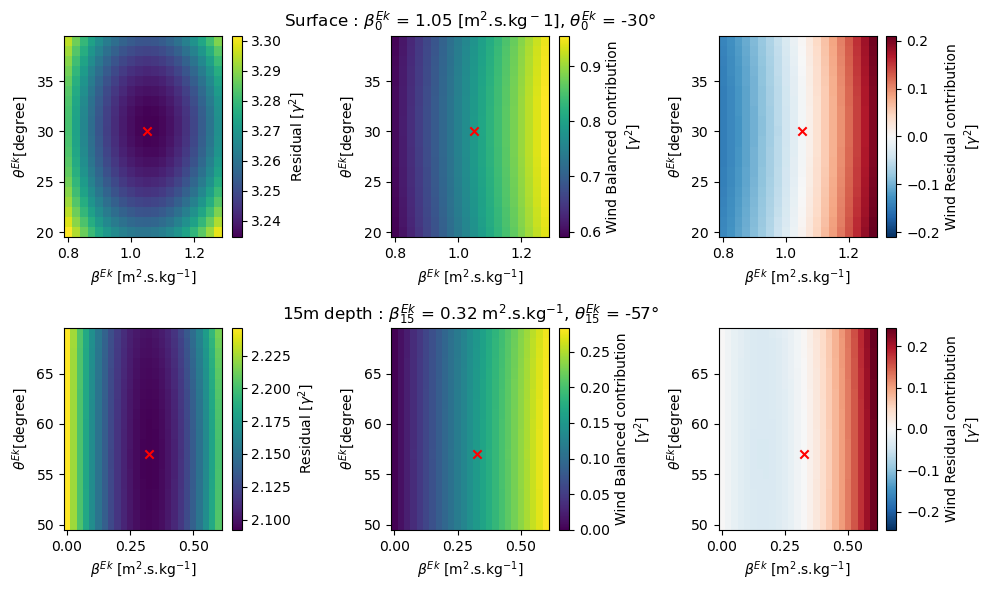

In [8]:
fig, axs = plt.subplots(2, 3, figsize = (10, 6), frameon=False)
axs= axs.flatten()

# Surface
dsm = dsm0
ax = axs[0]
dsm.S.assign_attrs({'long_name':'Residual', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
betamin = dsm.where(dsm.S == dsm.S.min(), drop=True).beta.values
thetamin = dsm.where(dsm.S == dsm.S.min(), drop=True).theta.values
ax.set_title('')
print(betamin, thetamin)

ax = axs[1]
(dsm.Be_wd +dsm.Bn_wd).assign_attrs({'long_name':'Wind Balanced contribution', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
ax.set_title(r'Surface : $\beta^{Ek}_0$'+rf' = {round(betamin[0], 2)} [m$^2$.s.kg$^{-1}$], '+r'$\theta^{Ek}_0$'+rf' = -{round(thetamin[0], 0)}°')

ax = axs[2]
(dsm.Ee_wd +dsm.En_wd).assign_attrs({'long_name':'Wind Residual contribution', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
ax.set_title('')

# 15m
dsm = dsm15
ax = axs[3]
dsm.S.assign_attrs({'long_name':'Residual', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
betamin = dsm.where(dsm.S == dsm.S.min(), drop=True).beta.values
thetamin = dsm.where(dsm.S == dsm.S.min(), drop=True).theta.values
ax.set_title('')
print(betamin, thetamin)

ax = axs[4]
(dsm.Be_wd +dsm.Bn_wd).assign_attrs({'long_name':'Wind Balanced contribution', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
ax.set_title(r'15m depth : $\beta^{Ek}_{15}$'+f' = {round(betamin[0], 2)}'+r' m$^2$.s.kg$^{-1}$, $\theta^{Ek}_{15}$ ='+f' -{round(thetamin[0], 0)}°')

ax = axs[5]
(dsm.Ee_wd +dsm.En_wd).assign_attrs({'long_name':'Wind Residual contribution', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
ax.set_title('')


for ax in axs :
    ax.set_xlabel(r'$\beta^{Ek}$ [m$^2$.s.kg$^{-1}$]')
    ax.set_ylabel(r'$\theta^{Ek}$[degree]')

    
fig.tight_layout()

[1.05] [30]
[0.325] [57]


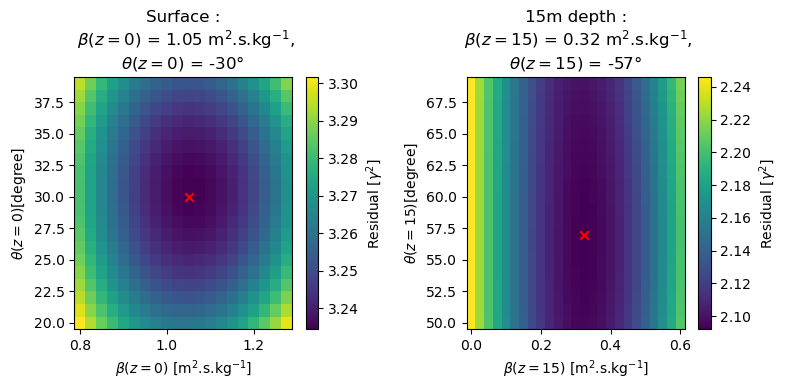

In [18]:
fig, axs = plt.subplots(1, 2, figsize = (8, 4), frameon=False)
axs= axs.flatten()

# Surface
dsm = dsm0
ax = axs[0]
dsm.S.assign_attrs({'long_name':'Residual', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
betamin = dsm.where(dsm.S == dsm.S.min(), drop=True).beta.values
thetamin = dsm.where(dsm.S == dsm.S.min(), drop=True).theta.values
ax.set_title('')
print(betamin, thetamin)
ax.set_xlabel(r'$\beta(z=0)$ [m$^2$.s.kg$^{-1}$]')
ax.set_ylabel(r'$\theta(z=0)$[degree]')
ax.set_title('Surface :\n '+r'$\beta(z=0)$'+f' = {round(betamin[0], 2)}'+r' m$^2$.s.kg$^{-1}$'+',\n'+r'$\theta(z=0)$ ='+f' -{round(thetamin[0], 0)}°')

# 15m
dsm = dsm15
ax = axs[1]
dsm.S.assign_attrs({'long_name':'Residual', 'units':r'$\gamma^2$'}).plot(ax=ax)
dsm.where(dsm.S == dsm.S.min(), drop=True).plot.scatter(x='beta', y='theta', marker = 'x', c='r', ax=ax)
betamin = dsm.where(dsm.S == dsm.S.min(), drop=True).beta.values
thetamin = dsm.where(dsm.S == dsm.S.min(), drop=True).theta.values
ax.set_title('')
print(betamin, thetamin)
ax.set_xlabel(r'$\beta(z=15)$ [m$^2$.s.kg$^{-1}$]')
ax.set_ylabel(r'$\theta(z=15)$[degree]')
ax.set_title('15m depth :\n '+r'$\beta(z=15)$'+f' = {round(betamin[0], 2)}'+r' m$^2$.s.kg$^{-1}$'+',\n'+r'$\theta(z=15)$ ='+f' -{round(thetamin[0], 0)}°')

    
fig.tight_layout()

fig, axs = plt.subplots(1, 3, figsize = (10, 3), frameon=False)

ax = axs[0]
dsm.S.sel(theta = thetamin, method='nearest').plot(ax=ax)
ax.axvline(betamin, ls=':', c='r')
ax.set_ylabel('Residual')
ax.set_xlabel(r'$\beta$ [m$^2$.s.kg$^{-1}$]')
ax = axs[1]
dsm.B_wd.sel(theta = thetamin, method='nearest').plot(ax=ax)
ax.set_ylabel('Wind Balanced contribution')
ax.set_xlabel(r'$\beta$ [m$^2$.s.kg$^{-1}$]')

ax = axs[2]
dsm.E_wd.sel(theta = thetamin, method='nearest').plot(ax=ax)
ax.axvline(betamin, ls=':', c='r')
ax.axhline(0, ls=':', c='r')
ax.set_ylabel('Wind residual contribution')
ax.set_xlabel(r'$\beta$ [m$^2$.s.kg$^{-1}$]')

for ax in axs :
    ax.grid()
fig.tight_layout()

fig, axs = plt.subplots(1, 3, figsize = (10, 3), frameon=False)

ax = axs[0]
dsm.S.sel(beta = betamin, method='nearest').plot(ax=ax)
ax.axvline(thetamin, ls=':', c='r')
ax.set_ylabel('Residual')

ax = axs[1]
dsm.B_wd.sel(beta = betamin).plot(ax=ax)
ax.axvline(thetamin, ls=':', c='r')
ax.set_ylabel('Wind Balanced contribution')

ax = axs[2]
dsm.E_wd.sel(beta = betamin).plot(ax=ax)
ax.axvline(thetamin, ls=':', c='r')
ax.set_ylabel('Wind residual contribution')


for ax in axs :
    ax.grid()
    
fig.tight_layout()

In [32]:
betamin, thetamin

(array([1.]), array([33.75]))

In [ ]:
# with finer grid : beta = 1.07916667, theta = 33.125